# Normal Distribution & The 68-95-99.7 Rule

## What is Normal Distribution?

The **Normal Distribution** (also called Gaussian Distribution) is a continuous probability distribution that is symmetric about the mean. It shows that data near the mean are more frequent in occurrence than data far from the mean.

### Key Properties:
- **Bell-shaped curve** – symmetric around the center
- **Mean = Median = Mode** – all are equal
- **Total area under the curve = 1** (100% probability)
- **Determined by two parameters:**
  - μ (mu) – mean (center of distribution)
  - σ (sigma) – standard deviation (spread of distribution)

### Why is it important in AI/ML?
- Many ML algorithms assume normal distribution of data
- Used in feature scaling, outlier detection, error analysis
- Basis for Central Limit Theorem
- Used in Gaussian Naive Bayes, Linear Regression, and many others

# The 68-95-99.7 Rule (Empirical Rule)

For any **normally distributed data**:

| Standard Deviations | Percentage of Data | Range |
|---------------------|-------------------|-------|
| 1σ (one sigma) | 68% | μ ± 1σ |
| 2σ (two sigma) | 95% | μ ± 2σ |
| 3σ (three sigma) | 99.7% | μ ± 3σ |

### Visual Representation:

```
                   68% within 1σ
               ┌─────────────────┐
          95% within 2σ          │
      ┌──────────────────────────┼──┐
  99.7% within 3σ                │  │
 ┌───────────────────────────────┼──┼──┐
 │                               │  │  │
 │    ┌─────┐                   │  │  │
 │   ╱       ╲                  │  │  │
 │  ╱         ╲                 │  │  │
 │ ╱           ╲                │  │  │
 ││             ││               │  │  │
    
─┴──┴──┴──┴──┴──┴──┴──┴──┴──┴─
-3σ -2σ -1σ  μ  +1σ +2σ +3σ
```

## 1. The 68% Rule (One Standard Deviation)

**Statement:** Approximately 68% of data points lie within 1 standard deviation of the mean.

**Range:** `[μ - σ, μ + σ]`

**Example:** If student test scores are normally distributed with μ = 70 and σ = 10, then 68% of students scored between 60 and 80.

**In ML Context:** Used for identifying typical data points. Points beyond 1σ might need attention but are not extreme outliers.

**Visual:**
```
        68% of area
    ┌─────────────────┐
    │                 │
   ╱│                 │╲
  ╱ │                 │ ╲
 ╱  │                 │  ╲
│   │                 │   │
─┴───┴─────────────────┴───┴─
   μ-σ       μ       μ+σ
```

## 2. The 95% Rule (Two Standard Deviations)

**Statement:** Approximately 95% of data points lie within 2 standard deviations of the mean.

**Range:** `[μ - 2σ, μ + 2σ]`

**Example:** Using the same test score example (μ=70, σ=10), 95% of students scored between 50 and 90.

**In ML Context:** Common threshold for confidence intervals. Used in anomaly detection – points beyond 2σ are considered potential anomalies.

**Visual:**
```
            95% of area
    ┌─────────────────────────┐
    │                         │
   ╱│                         │╲
  ╱ │                         │ ╲
 ╱  │                         │  ╲
│   │                         │   │
─┴───┴─────────────────────────┴───┴─
  μ-2σ          μ            μ+2σ
```

## 3. The 99.7% Rule (Three Standard Deviations)

**Statement:** Approximately 99.7% of data points lie within 3 standard deviations of the mean.

**Range:** `[μ - 3σ, μ + 3σ]`

**Example:** Using μ=70, σ=10, 99.7% of students scored between 40 and 100. Only 0.3% score outside this range.

**In ML Context:** Standard for outlier detection in quality control (Six Sigma). Points beyond 3σ are almost certainly outliers or errors.

**Visual:**
```
          99.7% of area
    ┌─────────────────────────────┐
    │                             │
   ╱│                             │╲
  ╱ │                             │ ╲
 ╱  │                             │  ╲
│   │                             │   │
─┴───┴─────────────────────────────┴───┴─
 μ-3σ            μ              μ+3σ
```

## Complete Summary Table

| Range | Coverage | Outside Range | Common Use |
|-------|----------|---------------|------------|
| μ ± 1σ | 68.27% | 31.73% | Typical variation |
| μ ± 2σ | 95.45% | 4.55% | Confidence interval |
| μ ± 3σ | 99.73% | 0.27% | Outlier detection |

## Practical Applications in AI/ML:

1. **Outlier Detection** – Remove points beyond 3σ
2. **Feature Scaling** – Standardization (Z-score normalization)
3. **Error Analysis** – Model residuals should follow normal distribution
4. **Confidence Intervals** – Model prediction uncertainty
5. **Anomaly Detection** – Identify rare events
6. **Quality Control** – Monitor model performance

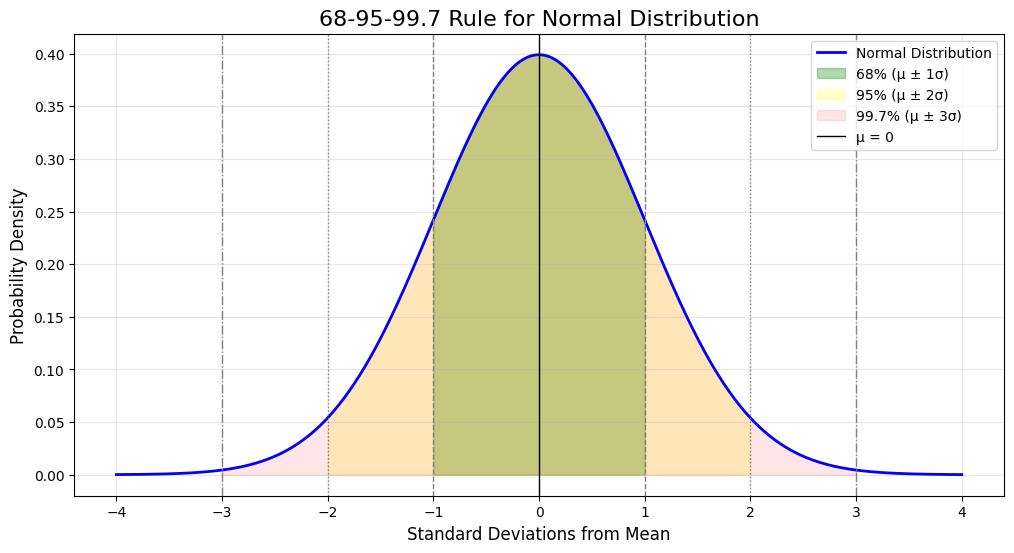

Data within 1σ: 68.27%
Data within 2σ: 95.45%
Data within 3σ: 99.73%


In [1]:
# Python Example: Visualizing the 68-95-99.7 Rule

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generate normal distribution data
mu, sigma = 0, 1  # mean and standard deviation
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, mu, sigma)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(x, y, 'b-', linewidth=2, label='Normal Distribution')

# Fill areas for different standard deviations
x_1sigma = np.linspace(mu - sigma, mu + sigma, 1000)
y_1sigma = stats.norm.pdf(x_1sigma, mu, sigma)
plt.fill_between(x_1sigma, y_1sigma, alpha=0.3, color='green', label='68% (μ ± 1σ)')

x_2sigma = np.linspace(mu - 2*sigma, mu + 2*sigma, 1000)
y_2sigma = stats.norm.pdf(x_2sigma, mu, sigma)
plt.fill_between(x_2sigma, y_2sigma, alpha=0.2, color='yellow', label='95% (μ ± 2σ)')

x_3sigma = np.linspace(mu - 3*sigma, mu + 3*sigma, 1000)
y_3sigma = stats.norm.pdf(x_3sigma, mu, sigma)
plt.fill_between(x_3sigma, y_3sigma, alpha=0.1, color='red', label='99.7% (μ ± 3σ)')

# Add vertical lines
plt.axvline(mu, color='black', linestyle='-', linewidth=1, label=f'μ = {mu}')
plt.axvline(mu + sigma, color='gray', linestyle='--', linewidth=1)
plt.axvline(mu - sigma, color='gray', linestyle='--', linewidth=1)
plt.axvline(mu + 2*sigma, color='gray', linestyle=':', linewidth=1)
plt.axvline(mu - 2*sigma, color='gray', linestyle=':', linewidth=1)
plt.axvline(mu + 3*sigma, color='gray', linestyle='-.', linewidth=1)
plt.axvline(mu - 3*sigma, color='gray', linestyle='-.', linewidth=1)

# Labels and title
plt.title('68-95-99.7 Rule for Normal Distribution', fontsize=16)
plt.xlabel('Standard Deviations from Mean', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

# Print percentages
print(f"Data within 1σ: {stats.norm.cdf(1) - stats.norm.cdf(-1):.2%}")
print(f"Data within 2σ: {stats.norm.cdf(2) - stats.norm.cdf(-2):.2%}")
print(f"Data within 3σ: {stats.norm.cdf(3) - stats.norm.cdf(-3):.2%}")